In [2]:
import jax.random as jrd
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.model as lsl

In [3]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)), lsl.Dist(tfd.Normal, loc=x, scale=1.0), name="y"
)

model = lsl.Model([y])

W0320 15:53:35.111224  602609 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


In [4]:
# model.plot()

In [5]:
model.locked = False
y.dist_node["scale"] = lsl.Var.new_param(2.0, name="scale")

# model.plot()

In [6]:
y.dist_node["scale"]

Var(name="scale")

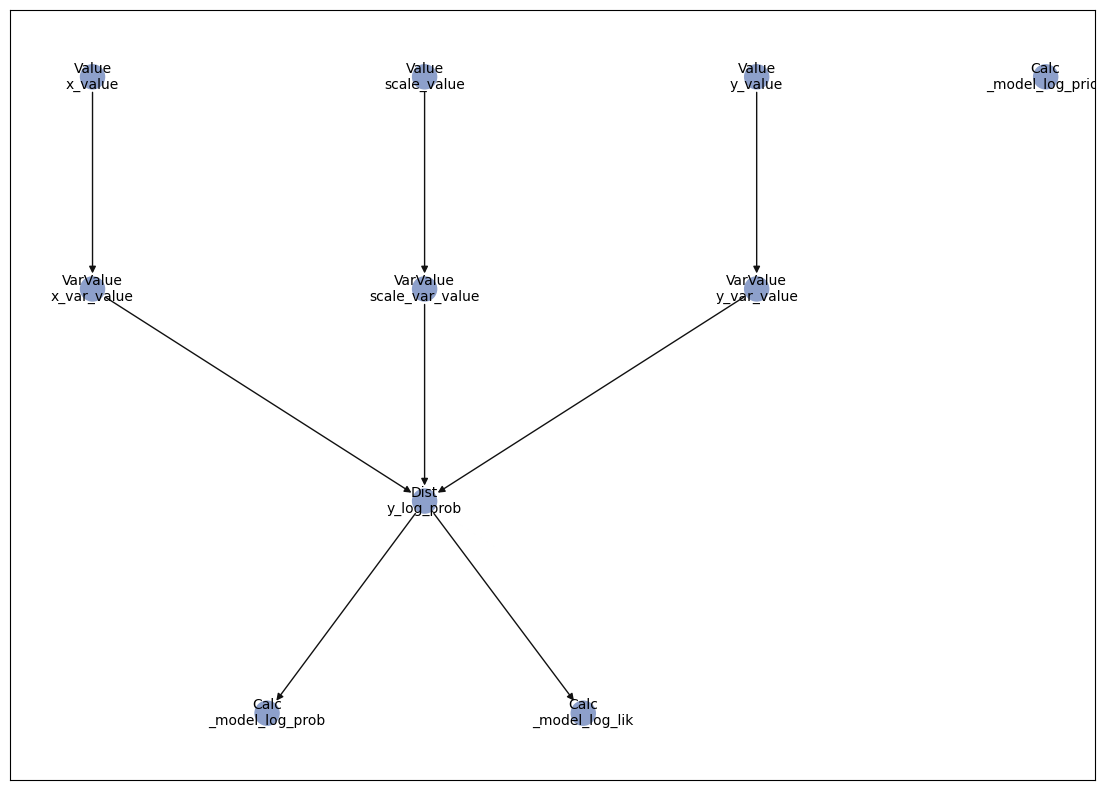

In [7]:
model.plot_nodes()

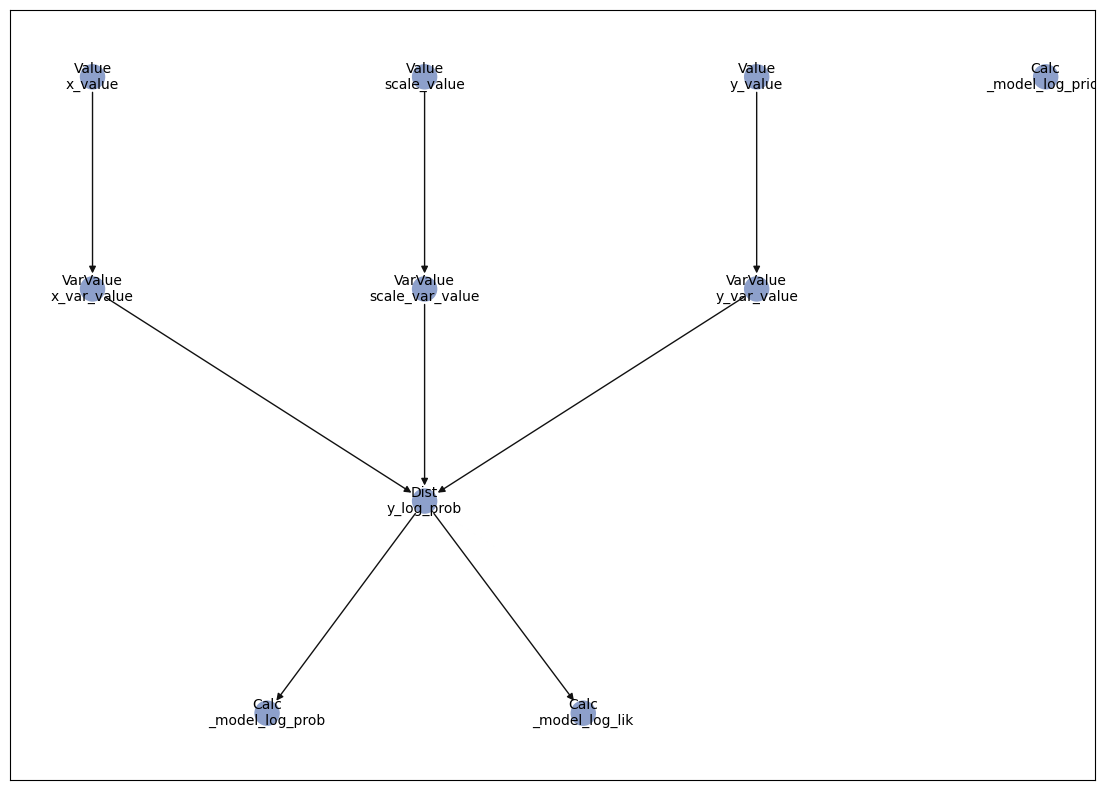

In [8]:
model.drop_singletons().plot_nodes()

In [9]:
# model.plot()

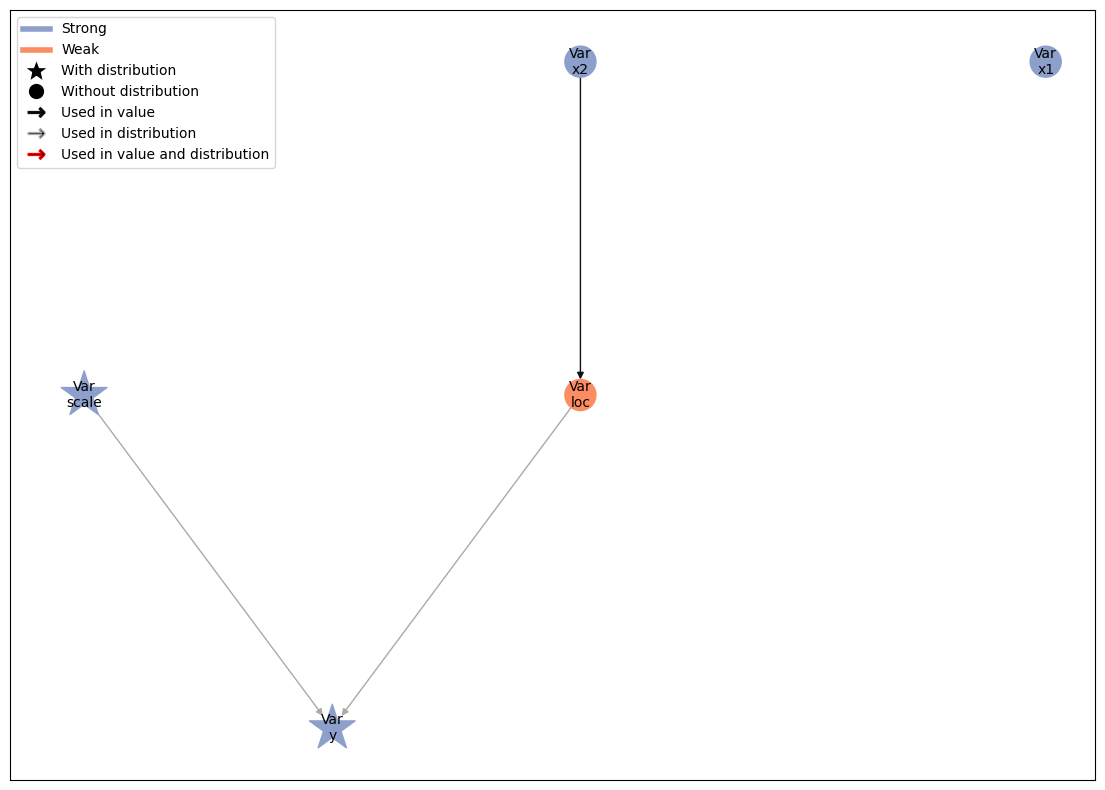

In [10]:
x1 = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x1")
x2 = lsl.Var.new_obs(jrd.normal(jrd.key(2), (10,)), name="x2")
x3 = jrd.normal(jrd.key(3), (10,))

loc = lsl.Var.new_calc(lambda *args: sum(args), x1, x2, name="loc")

scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(tfd.Normal, loc=0.0, scale=1.0),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)),
    lsl.Dist(tfd.Normal, loc=loc, scale=scale),
    name="y",
)

model = lsl.Model([y])
model.locked = False

loc.value_node[0] = x3

model.plot_vars()

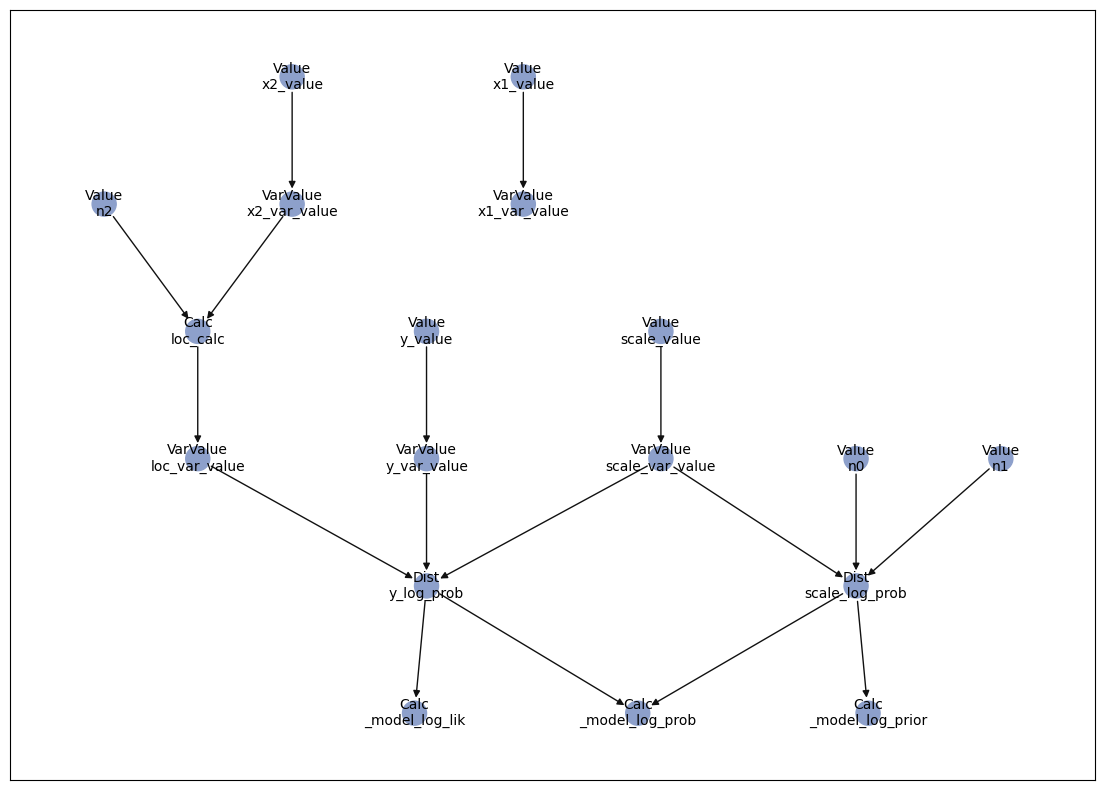

In [11]:
model.plot_nodes()

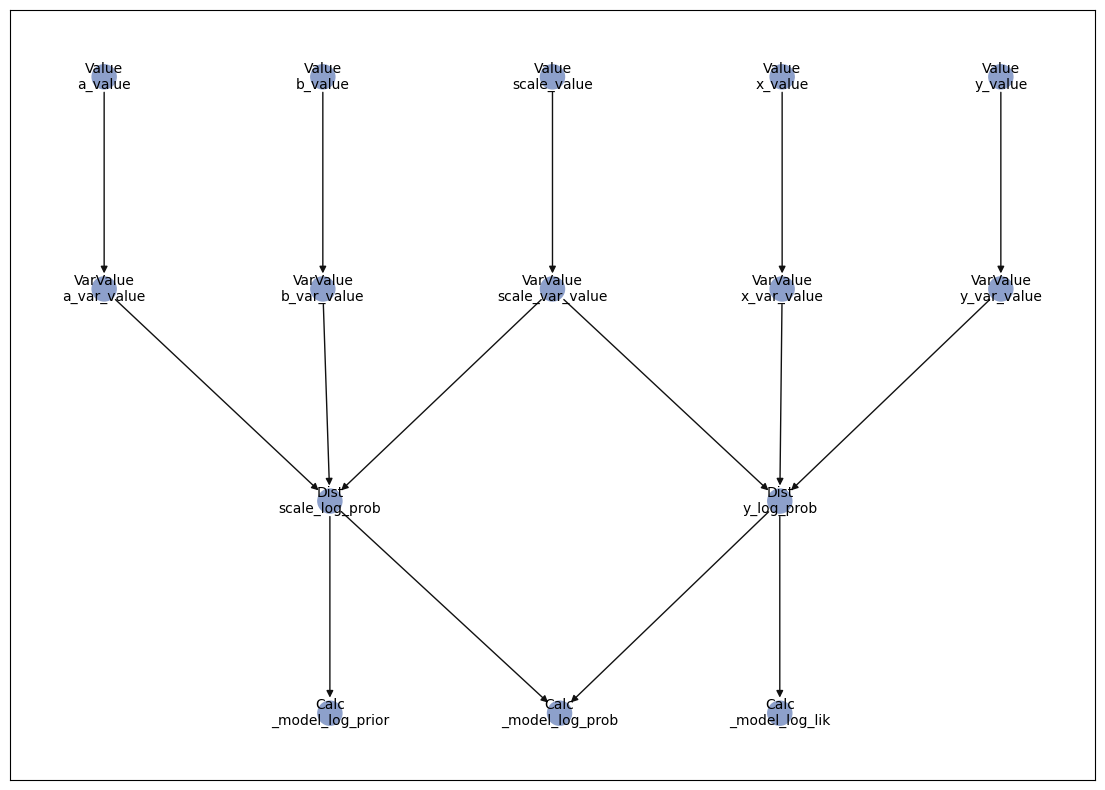

In [12]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)),
    lsl.Dist(tfd.Normal, loc=x, scale=scale),
    name="y",
)

model = lsl.Model([y])
model.locked = False
model.plot_nodes()

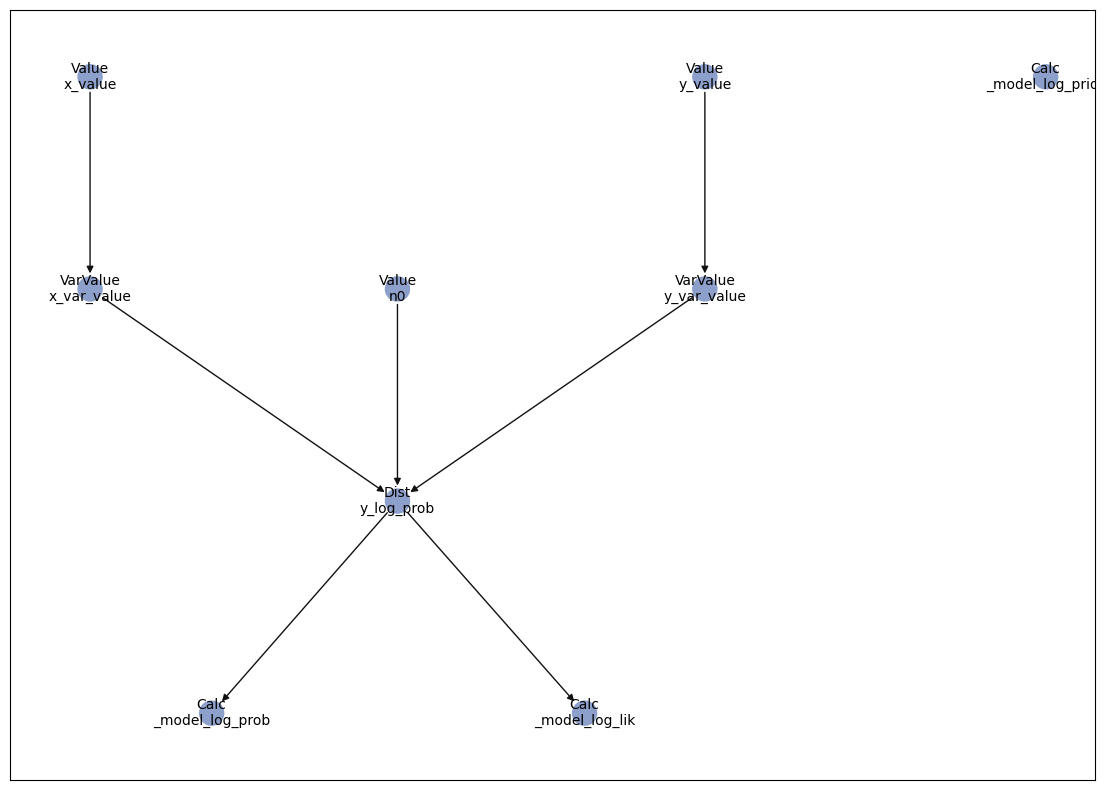

In [13]:
x = lsl.Var.new_obs(jrd.normal(jrd.key(1), (10,)), name="x")
scale = lsl.Var.new_param(
    1.0,
    lsl.Dist(
        tfd.InverseGamma,
        concentration=lsl.Var.new_param(1.0, name="a"),
        scale=lsl.Var.new_param(1.0, name="b"),
    ),
    name="scale",
)

y = lsl.Var.new_obs(
    jrd.normal(jrd.key(2), (10,)),
    lsl.Dist(tfd.Normal, loc=x, scale=scale),
    name="y",
)

model = lsl.Model([y])
model.locked = False
model.replace(scale, 10.0)
model.plot_nodes()